In [101]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import itertools
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(42)

# go-mHC Class
class GeneralizedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, orthonormal=True, init=torch.rand):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.total_dim = d * s
        
        # Add a batch dimension: (batch_size, ds, ds)
        self.raw_u = nn.Parameter(init(
            self.batch_size, self.total_dim, self.total_dim, 
            dtype=torch.float32 if orthonormal else torch.complex64
        ))

    def get_unitary(self):
        # Batch-wise adjoint and matrix exponential
        ru = self.raw_u
        
        X = ru - ru.adjoint() 
        # Can instead do matrix exp, but that is worse for many reasons (stability, number of operations, etc.)
        # return torch.matrix_exp(X)
        
        # Cayley Transform
        I = torch.eye(self.total_dim, device=X.device).unsqueeze(0).expand(self.batch_size, -1, -1)
        U = torch.linalg.solve(I - X, I + X)
        return U

    def forward(self):
        U = self.get_unitary()
        
        # Reshape to (batch, d, s, d, s) -> (batch, d, d, s, s)
        blocks = U.view(self.batch_size, self.d, self.s, self.d, self.s).permute(0, 1, 3, 2, 4)
        
        # Sum across the internal s x s blocks for the whole batch
        bistochastic_matrices = torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / self.s
        
        return bistochastic_matrices

class AveragedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, free_s=False):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.free_s = free_s
    
        self.raw_u = nn.Parameter(torch.rand(
            self.batch_size, self.s, self.d, self.d, 
            dtype=torch.float32
        ))
        
        # if self.s >= 2:
        #     with torch.no_grad():
        #         # set second matrix init to something that makes identity
        #         self.raw_u[:, 1, :, :] = 10*torch.rand(
        #             self.batch_size, self.d, self.d, 
        #             dtype=torch.float32
        #         )

        if free_s:
            self.s_param = nn.Parameter(torch.rand(self.s))
        
    def get_unitary(self):
        # Batch-wise adjoint and cayley transform using solve
        X = self.raw_u - self.raw_u.transpose(-2, -1)
        I = torch.eye(self.d, device=X.device).expand_as(X)
        return torch.linalg.solve(I - 0.5 * X, I + 0.5 * X)
    
    def forward(self):
        U = self.get_unitary()
        
        if self.free_s:
            # map learned s_param to values between 0 and 1 that sum to 1 using sigmoid and normalization
            sigmoid_s = torch.sigmoid(self.s_param)
            prefactors = sigmoid_s / sigmoid_s.sum()
        # else:
        #     prefactors = 1.0 / self.s
        
        # take squared of U
        u_squared = torch.abs(U) ** 2
        
        # average over s
        if self.free_s:
            # print("shapes", u_squared.shape, prefactors.shape)
            s_avg = torch.einsum('bsot, s -> bot', u_squared, prefactors)
        else:
            s_avg = u_squared.sum(dim=1) / self.s
        
        return s_avg
    
    
# get all nxn permutation matrices as a tensor of shape (n!, n, n)
def get_permutation_matrices(n):
    perms = list(itertools.permutations(range(n)))
    matrices = [torch.zeros(n, n).index_put_((torch.arange(n), torch.tensor(p)), torch.tensor(1.0)) for p in perms]
    return torch.stack(matrices)

# Sinkhorn normalization to make a matrix doubly stochastic (same as in mHC paper)
# Repeatedly normalize rows and columns until convergence (or max iterations)
def sinkhorn(M, num_iters=20):
    # check if M is already doubly stochastic
    if torch.allclose(M.sum(dim=-1), torch.ones(M.shape[0], M.shape[1]), atol=1e-8) and torch.allclose(M.sum(dim=-2), torch.ones(M.shape[0], M.shape[2]), atol=1e-8):
        return M
    # Works on [B, n, n]
    for _ in range(num_iters):
        M = abs(M)  # Ensure non-negativity
        M = M / M.sum(dim=-1, keepdim=True)  # Row
        M = M / M.sum(dim=-2, keepdim=True)  # Col
    return M

# Class that implements both mHC-lite and KromHC
# To do KromHC, you have multiple num_factors and N=2 (num_factors is log2 of the dimension of the matrix)
# To do mHC-lite, you have num_factors=1 and N=n (the dimension of the matrix)
class GeneralizedKromHC(nn.Module):
    def __init__(self, num_factors, N=3, batch_size=1):
        super().__init__()
        self.num_factors = num_factors
        self.N = N
        self.batch_size = batch_size
        
        # Precompute all N! permutation matrices
        perms = list(itertools.permutations(range(N)))
        self.num_perms = len(perms)
        
        perm_mats = torch.zeros((self.num_perms, N, N))
        for i, p in enumerate(perms):
            for row, col in enumerate(p):
                perm_mats[i, row, col] = 1.0
        self.register_buffer('perm_mats', perm_mats)

        # Logits for the convex combination
        self.coeffs = nn.Parameter(torch.randn(batch_size, num_factors, self.num_perms))

    def forward(self):
        weights = F.softmax(self.coeffs, dim=-1) 
        
        # Build factor matrices: (Batch, Num_Factors, N, N)
        factor_mats = (weights.view(self.batch_size, self.num_factors, self.num_perms, 1, 1) * self.perm_mats.view(1, 1, self.num_perms, self.N, self.N)).sum(dim=2)
        
        res = factor_mats[:, 0, :, :]
        
        for k in range(1, self.num_factors):
            mat = factor_mats[:, k, :, :]
            curr_dim = res.shape[1]
            
            res_expanded = res.view(self.batch_size, curr_dim, 1, curr_dim, 1)
            mat_expanded = mat.view(self.batch_size, 1, self.N, 1, self.N)
            
            res = (res_expanded * mat_expanded).reshape(
                self.batch_size, curr_dim * self.N, curr_dim * self.N
            )
        return res

# Parameter Sweeps

In [102]:
from functools import cache

import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# --- Core Experiment Function ---
import pickle
import os
from functools import wraps
from frozendict import frozendict


def file_cache(filename):
    """
    A decorator that caches the result of a function to a file.
    The cache persists across different runs of the program.
    Note: This simple version works best for functions with no arguments
    or if all calls use the same arguments, as it uses a single cache file.
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # A more robust implementation would use a key based on args/kwargs
            # in the filename if different inputs are expected.
            cache_file = filename 

            if len(args) > 1 or len(kwargs) > 0:
                raise NotImplementedError("This simple file cache only supports functions with a single argument (the config dict).")

            config = frozendict(args[0])

            if os.path.exists(cache_file):
                try: 
                    with open(cache_file, 'rb') as f:
                        print(f"Loading result from cache file: {cache_file}")

                        cached_data = pickle.load(f)
                        if config in cached_data:
                            return cached_data[config]
                except Exception as e:
                    print(f"Error loading cache: {e}. Recomputing.")
            else:
                cached_data = {}

            # If cache doesn't exist or failed to load, run the function
            result = func(*args, **kwargs)

            # Save the result to the cache file
            with open(cache_file, 'wb') as f:
                #instead of dumpting, add a value to dict with key config
                cached_data[config] = result
                pickle.dump(cached_data, f)
            
            print(f"Computed result and saved to cache file: {cache_file}")
            return result
        return wrapper
    return decorator

# Example Usage
@file_cache('toy_model_cache.pkl')
def run_single_experiment(config):
    """
    Runs one training session with a specific configuration.
    Returns the final metrics and history for plotting.
    """
    # 1. Setup local hyperparams from config
    n = config['n']
    B = config['B']
    lr = config['lr']
    sparsity = config['sparsity']
    num_epochs = config['num_epochs']
    dataset_size = config['dataset_size']
    noise_mag = config['noise_mag']
    
    include_H_pre = config['include_H_pre']  # Whether to include the pre_layer transformation in targets
    
    # 2. Data Generation (Target T and Inputs X)
    # Assuming get_permutation_matrices and sinkhorn are defined in your scope
    #P = get_permutation_matrices(n)
    #T = 0.7*P[0] + 0.3*torch.roll(P[0], shifts=1, dims=1)  # A simple bistochastic matrix (average of two permutations)
    #T = T.unsqueeze(0).expand(B, -1, -1)  # Expand to batch size
    T = sinkhorn(torch.rand(B, n, n))
    # Y = T
    # T += (noise_mag * torch.rand_like(T))
    
    # T = abs(T)
    
    # X = T
    
    
    X = torch.rand(B, dataset_size, n)
    sparse_mask = (torch.rand_like(X) > sparsity).float()
    X = X * sparse_mask.sum(dim=-1, keepdim=True)
    Y = torch.einsum('bij,bkj->bki', T, X) + (noise_mag * torch.rand(B, dataset_size, n))
    
    if include_H_pre:
        pre_layer_target = torch.rand(1, n)  # Target for the pre_layer to learn
        Y = torch.einsum('ij,bkj->bki', pre_layer_target, Y)  # Apply the same pre_layer transformation to targets

    # 3. Model Initialization
    # You can expand this to test different model subsets
    exp_models = {
        "gu_1": GeneralizedUnistochastic(n, 1, B),
        "gu_2": GeneralizedUnistochastic(n, 2, B),
        "gu_3": GeneralizedUnistochastic(n, 3, B),
    }

    if n < 7:
        exp_models["mhc_lite"] = GeneralizedKromHC(num_factors=1, N=n, batch_size=B)
    
    if int(np.log2(n)) == np.log2(n):
        exp_models["kromhc"] = GeneralizedKromHC(num_factors=int(np.log2(n)), N=2, batch_size=B)
    
    if include_H_pre:
        # create a 1xn layer initialized to all 1s for each model
        pre_layer_init = torch.ones(1, n) + 0.1*torch.randn(1, n)
        pre_layer = {i: nn.Parameter(pre_layer_init.clone(), requires_grad=True) for i in exp_models.keys()}

    # 4. Optimization Setup
    criterion = nn.MSELoss(reduction='none')
    adam_params = dict(lr=lr)
    if include_H_pre:
        optimizers = {
            name: optim.Adam([{'params': m.parameters()}, {'params': pre_layer[name]}], **adam_params) for name, m in exp_models.items()
        }
    else:
        optimizers = {
            name: optim.Adam(m.parameters(), **adam_params) for name, m in exp_models.items()
        }
    
    # 5. Training Loop
    local_history = {name: np.zeros((B, num_epochs)) for name in exp_models.keys()}
    
    for epoch in range(num_epochs):
        for name, model in exp_models.items():

            opt = optimizers[name]
            opt.zero_grad()
            
            output = model()
            tildeY = torch.einsum('bij,bkj->bki', output, X)
            
            # set tildeY to be pre_layer[name] @ tildeY
            if include_H_pre:
                tildeY = torch.einsum('ij,bkj->bki', pre_layer[name], tildeY)
            
            individual_losses = criterion(tildeY, Y)

            loss=torch.mean(individual_losses)

            # loss = criterion(Y, model())
            loss.backward()
            opt.step()
            
            with torch.no_grad():
                local_history[name][:,epoch] = individual_losses.mean(axis=[1,2]).detach().cpu().numpy()
            
    # Return final loss for each model as a summary
    summary = {f"final_loss_{k}": v[-1] for k, v in local_history.items()}
    return summary, local_history

In [103]:
def run_sweep(sweep_config):
    # fix seeds
    seed = 42
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Generate all combinations
    keys, values = zip(*sweep_config.items())
    experiments = [dict(zip(keys, v)) for v in product(*values)]

    print(f"Total experiments to run: {len(experiments)}")

    # --- Execution ---
    all_results = []
    all_histories = {}
    for i, config in enumerate(experiments):
        print(f"Running Experiment {i+1}/{len(experiments)}: {config}")
        summary, hist = run_single_experiment(config)
        print("hist:", hist)
        
        # Merge config and summary for a flat row
        result_row = {**config, **summary}
        all_results.append(result_row)
        all_histories[i] = hist

    print("Sweep Complete!")
    return all_results, all_histories

# Loss Trajectories

In [104]:
sweep_config = {
    'n': [2],
    'lr': [0.001],#, 0.005],
    'sparsity': [0.0005], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [3],
    'num_epochs': [10],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 1
Running Experiment 1/1: {'n': 2, 'lr': 0.001, 'sparsity': 0.0005, 'B': 3, 'num_epochs': 10, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.01570632, 0.01511553, 0.01453864, 0.01397597, 0.01342786,
        0.01289455, 0.01237642, 0.01187367, 0.01138653, 0.01091524],
       [0.11208609, 0.11185774, 0.11161266, 0.11135067, 0.11107159,
        0.11077517, 0.11046116, 0.11012928, 0.10977926, 0.10941082],
       [0.03964323, 0.03903254, 0.03841967, 0.03780483, 0.03718822,
        0.03657008, 0.03595068, 0.03533022, 0.03470897, 0.03408721]]), 'gu_2': array([[0.00655391, 0.00634745, 0.00614912, 0.00595899, 0.00577707,
        0.00560334, 0.00543773, 0.00528018, 0.00513055, 0.00498874],
       [0.00475758, 0.00455859, 0.00437484, 0.00420654, 0.00405371,
        0.00391638, 0.00379442, 0.00368758, 0.00359547, 0.00351756],
       [0.04847889, 0.04795752, 0.04742461, 0.04688034,

In [105]:
all_histories


{0: {'gu_1': array([[0.01570632, 0.01511553, 0.01453864, 0.01397597, 0.01342786,
          0.01289455, 0.01237642, 0.01187367, 0.01138653, 0.01091524],
         [0.11208609, 0.11185774, 0.11161266, 0.11135067, 0.11107159,
          0.11077517, 0.11046116, 0.11012928, 0.10977926, 0.10941082],
         [0.03964323, 0.03903254, 0.03841967, 0.03780483, 0.03718822,
          0.03657008, 0.03595068, 0.03533022, 0.03470897, 0.03408721]]),
  'gu_2': array([[0.00655391, 0.00634745, 0.00614912, 0.00595899, 0.00577707,
          0.00560334, 0.00543773, 0.00528018, 0.00513055, 0.00498874],
         [0.00475758, 0.00455859, 0.00437484, 0.00420654, 0.00405371,
          0.00391638, 0.00379442, 0.00368758, 0.00359547, 0.00351756],
         [0.04847889, 0.04795752, 0.04742461, 0.04688034, 0.04632486,
          0.0457583 , 0.04518074, 0.04459236, 0.0439933 , 0.04338372]]),
  'gu_3': array([[0.03527481, 0.03424887, 0.03324086, 0.03225128, 0.03128047,
          0.03032878, 0.02939653, 0.02848397, 0.02759

# Loss Trajectories by # of residual streams and sparsity

In [106]:
sweep_config = {
    'n': [2, 3, 4, 5, 6, 7, 8, 10, 12],
    #fig 8: 'n': [2, 3, 4, 5, 6, 7, 8, 10],

    'lr': [0.001],#, 0.005],
    'sparsity': [0, 0.5, 0.9], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 27
Running Experiment 1/27: {'n': 2, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.00676362, 0.00643594, 0.00612427, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.03648835, 0.0356864 , 0.03489156, ..., 0.00339938, 0.00339938,
        0.00339938],
       [0.05187423, 0.05059893, 0.04933788, ..., 0.00307797, 0.00307797,
        0.00307798],
       ...,
       [0.00339   , 0.00334009, 0.00330439, ..., 0.00327341, 0.00327342,
        0.00327342],
       [0.26870361, 0.26866591, 0.26860654, ..., 0.00318493, 0.00318493,
        0.00318493],
       [0.14133497, 0.13952139, 0.13771453, ..., 0.00322654, 0.00322654,
        0.00322654]], shape=(64, 10000)), 'gu_2': array([[0.0112594 , 0.01120432, 0.0111513 , ..., 0.00325113, 0.00325114,
        0.00325115],
       [0.0037635 , 0.00367132, 0.00359275, ..., 0

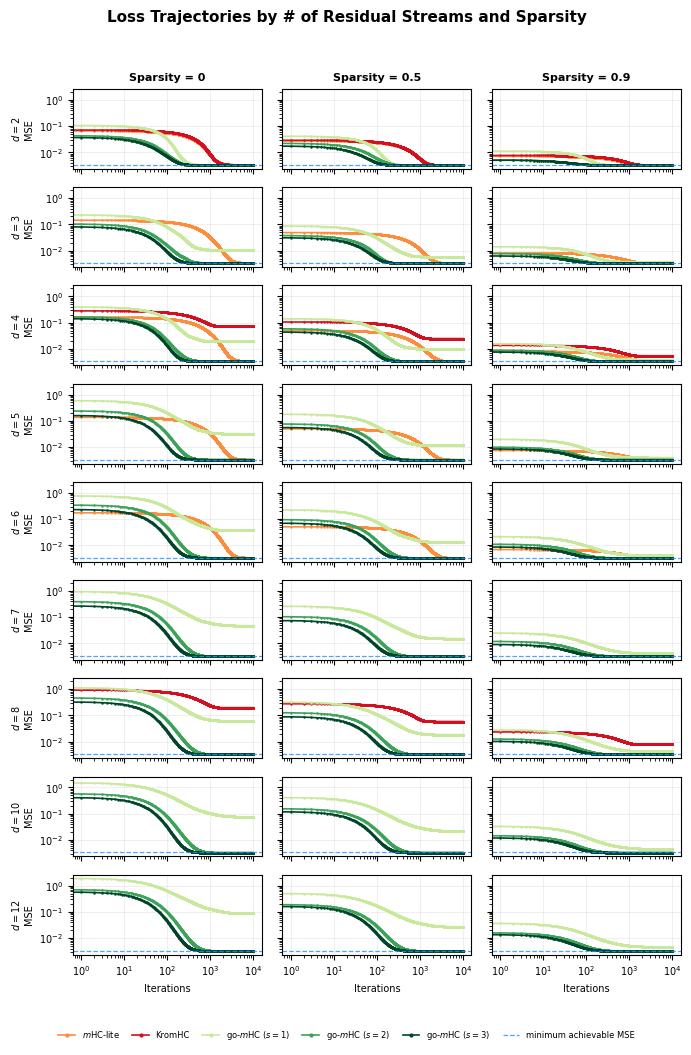

In [107]:
import matplotlib.pyplot as plt
import numpy as np

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 3)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})

noise_floor = (sweep_config['noise_mag'][0] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

n_values = sweep_config['n']
sparsity_values = sweep_config['sparsity']

n_rows = len(n_values)
n_cols = len(sparsity_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=FIG_SIZE, sharex=True, sharey=True)

fig.suptitle("Loss Trajectories by # of Residual Streams and Sparsity",
             fontsize=11, fontweight='bold')

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])

for col, s in enumerate(sparsity_values):
    axes[0, col].set_title(f"Sparsity = {s}", fontsize=8, fontweight='bold')

for row, (n_idx, d) in enumerate(enumerate(n_values)):
    for col, (s_idx, s) in enumerate(enumerate(sparsity_values)):
        ax = axes[row, col]
        exp_idx = n_idx * len(sparsity_values) + s_idx

        histories = {
            '$m$HC-lite': [],
            'KromHC': [],
            ' ': [],
            'go-$m$HC ($s=1$)': all_histories[exp_idx].get('gu_1', []),
            'go-$m$HC ($s=2$)': all_histories[exp_idx].get('gu_2', []),
            'go-$m$HC ($s=3$)': all_histories[exp_idx].get('gu_3', []),
        }
        if d.bit_count() == 1:
            histories['KromHC'] = all_histories[exp_idx].get('kromhc', [])
        if d < 7:
            histories['$m$HC-lite'] = all_histories[exp_idx].get('mhc_lite', [])

        i = 0
        for label in histories:
            data = histories[label]

            if data is not None and (hasattr(data, '__len__') and len(data) > 0):
                avg_data = np.mean(data, axis=0)
                ax.plot(avg_data, color=colors[i],
                        alpha=0 if label == " " else 1,
                        marker='.', markersize=1.5, rasterized=True)
            i += 1

        # Noise floor line
        ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.grid(True, which="major", ls="-", alpha=0.2)

        if col == 0:
            ax.set_ylabel(f"$d={d}$\nMSE", fontsize=7)
        if row == n_rows - 1:
            ax.set_xlabel("Iterations", fontsize=7)

from matplotlib.lines import Line2D

legend_labels = ['$m$HC-lite', 'KromHC', 'go-$m$HC ($s=1$)',
                 'go-$m$HC ($s=2$)', 'go-$m$HC ($s=3$)', 'minimum achievable MSE']
legend_colors = [colors[0], colors[1], colors[3], colors[4], colors[5]]

handles = [Line2D([0], [0], color=c, marker='.', markersize=4, lw=1.2, label=l)
           for c, l in zip(legend_colors, legend_labels[:-1])]

# Noise floor handle added separately to match its distinct style
handles.append(Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8,
                       label='minimum achievable MSE'))

fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.01),
           ncol=len(handles),
           frameon=False,
           fontsize=6,
           columnspacing=1.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('loss_traj_sparsity_grid.pdf', bbox_inches='tight', dpi=300)
plt.show()

# MSE by matrix dimension

In [149]:
sweep_config = {
    'n': [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16],
    'lr': [0.001],#, 0.005],
    'sparsity': [0], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 11
Running Experiment 1/11: {'n': 2, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.00676362, 0.00643594, 0.00612427, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.03648835, 0.0356864 , 0.03489156, ..., 0.00339938, 0.00339938,
        0.00339938],
       [0.05187423, 0.05059893, 0.04933788, ..., 0.00307797, 0.00307797,
        0.00307798],
       ...,
       [0.00339   , 0.00334009, 0.00330439, ..., 0.00327341, 0.00327342,
        0.00327342],
       [0.26870361, 0.26866591, 0.26860654, ..., 0.00318493, 0.00318493,
        0.00318493],
       [0.14133497, 0.13952139, 0.13771453, ..., 0.00322654, 0.00322654,
        0.00322654]], shape=(64, 10000)), 'gu_2': array([[0.0112594 , 0.01120432, 0.0111513 , ..., 0.00325113, 0.00325114,
        0.00325115],
       [0.0037635 , 0.00367132, 0.00359275, ..., 0

In [109]:
all_histories[0]

{'gu_1': array([[0.00676362, 0.00643594, 0.00612427, ..., 0.00325114, 0.00325114,
         0.00325114],
        [0.03648835, 0.0356864 , 0.03489156, ..., 0.00339938, 0.00339938,
         0.00339938],
        [0.05187423, 0.05059893, 0.04933788, ..., 0.00307797, 0.00307797,
         0.00307798],
        ...,
        [0.00339   , 0.00334009, 0.00330439, ..., 0.00327341, 0.00327342,
         0.00327342],
        [0.26870361, 0.26866591, 0.26860654, ..., 0.00318493, 0.00318493,
         0.00318493],
        [0.14133497, 0.13952139, 0.13771453, ..., 0.00322654, 0.00322654,
         0.00322654]], shape=(64, 10000)),
 'gu_2': array([[0.0112594 , 0.01120432, 0.0111513 , ..., 0.00325113, 0.00325114,
         0.00325115],
        [0.0037635 , 0.00367132, 0.00359275, ..., 0.00339938, 0.00339938,
         0.00339939],
        [0.02972367, 0.02953271, 0.02935527, ..., 0.00307797, 0.00307798,
         0.00307797],
        ...,
        [0.07021927, 0.06921129, 0.06821387, ..., 0.00327341, 0.00327341,

noise_floor 0.003333333333333334
val: 0.008331344008183805
val: 0.01579177962776157
val: 0.020857100189459743
val: 0.03126685132156126
val: 0.04718705892446451
val: 0.053857837949180976
val: 0.06407687443424948
val: 0.07644769351463765
val: 0.09777368605136871
val: 0.12388111464679241
val: 0.145900993142277
val: 0.0033419046667404473
val: 0.003371759499714244
val: 0.0033383204572601244
val: 0.00332740060184733
val: 0.0033486263382656034
val: 0.0033011209707183298
val: 0.0033309612517768983
val: 0.003334670458571054
val: 0.003337090322020231
val: 0.0033731300973158795
val: 0.003418309694097843
val: 0.0033419045466871466
val: 0.0033522841258672997
val: 0.0033229653163289186
val: 0.0033070530407712795
val: 0.003316503578389529
val: 0.0032632722177368123
val: 0.0032806679810164496
val: 0.0032580660918029025
val: 0.0032500074376002885
val: 0.0032202988186327275
val: 0.003210282218788052
val: 0.05592871503176866
val: 0.125269302574452
val: 0.141079323773738
val: 0.1190664577879943
val: 0.153

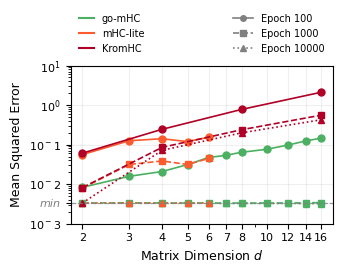

In [155]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

noise_floor = (sweep_config['noise_mag'][0] ** 2) / 3
print("noise_floor", noise_floor)

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC': plt.cm.YlOrRd(0.9),
}
epoch_indices = [99, 999, 9999]
epoch_markers = {99: 'o', 999: 's', 9999: '^'}
epoch_linestyles = {99: '-', 999: '--', 9999: ':'}

dims = sweep_config['n']

def get_loss_at_epoch(history_list, epoch_idx):
    if history_list is None or (hasattr(history_list, '__len__') and len(history_list) == 0):
        return None
    if epoch_idx >= len(history_list):
        return None
    return history_list[epoch_idx]

fig, ax = plt.subplots(figsize=FIG_SIZE)

for method_name, method_key_fn in [
    ('go-mHC', lambda dim: all_histories[dim].get('gu_2', [])),
    ('mHC-lite', lambda dim: all_histories[dim].get('mhc_lite', [])),
    ('KromHC', lambda dim: all_histories[dim].get('kromhc', [])),
]:
    color = colors_methods[method_name]
    for epoch in epoch_indices:

        xs = []
        ys = []
        for dim_idx, d in enumerate(dims):
            hist = method_key_fn(dim_idx)
            avg_hist = np.mean(hist, axis=0) if hist is not None and len(hist) > 0 else None

            if method_name == 'KromHC' and d.bit_count() != 1:
                continue
            if method_name == 'mHC-lite' and d >= 7:
                continue
            val = get_loss_at_epoch(avg_hist, epoch)
            print('val:', val)

            if val is not None:
                xs.append(d)
                ys.append(val)
        if xs:
            ax.plot(xs, ys,
                    color=color,
                    marker=epoch_markers[epoch],
                    linestyle=epoch_linestyles[epoch],
                    markersize=5,
                    rasterized=True)

ax.axhline(y=noise_floor, color='gray', linestyle='--', linewidth=0.9, alpha=0.8)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# --- Inject noise_floor into y-ticks ---
#ax.set_ylim(1e-3, 1e0)

existing_ticks = ax.get_yticks()
new_ticks = np.append(existing_ticks, noise_floor)
new_labels = ['$' + ax.yaxis.get_major_formatter().format_data(t)+ '$' for t in existing_ticks] + ['min']
ax.set_yticks(new_ticks)
ax.set_yticklabels(new_labels)

ax.set_ylim(1e-3, 1e1)

# Style the "min" tick label distinctively
for tick, label in zip(ax.yaxis.get_major_ticks(), ax.get_yticklabels()):
    if label.get_text() == 'min':
        tick.label1.set_color('gray')
        tick.label1.set_fontstyle('italic')

ax.set_xlabel("Matrix Dimension $d$")
ax.set_ylabel("Mean Squared Error")
ax.grid(True, which="major", ls="-", alpha=0.2)

# --- Two-column legend above the plot ---
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC']
]
epoch_handles = [
    Line2D([0], [0], color='gray', marker=epoch_markers[e],
           linestyle=epoch_linestyles[e], lw=1.2, markersize=4, label=f'Epoch {e+1}')
    for e in epoch_indices
]

legend1 = ax.legend(handles=method_handles,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=1.5)
legend2 = ax.legend(handles=epoch_handles,
                    loc='lower right',
                    bbox_to_anchor=(1.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=2.0)
ax.add_artist(legend1)

print("noise: ", sweep_config['noise_mag'])

plt.savefig('mse_vs_dim_high_noise.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Time to convergence by matrix dimension

In [118]:
sweep_config = {
    'n': [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16],
    'lr': [0.001],#, 0.005],
    'sparsity': [0], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 11
Running Experiment 1/11: {'n': 2, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.00676362, 0.00643594, 0.00612427, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.03648835, 0.0356864 , 0.03489156, ..., 0.00339938, 0.00339938,
        0.00339938],
       [0.05187423, 0.05059893, 0.04933788, ..., 0.00307797, 0.00307797,
        0.00307798],
       ...,
       [0.00339   , 0.00334009, 0.00330439, ..., 0.00327341, 0.00327342,
        0.00327342],
       [0.26870361, 0.26866591, 0.26860654, ..., 0.00318493, 0.00318493,
        0.00318493],
       [0.14133497, 0.13952139, 0.13771453, ..., 0.00322654, 0.00322654,
        0.00322654]], shape=(64, 10000)), 'gu_2': array([[0.0112594 , 0.01120432, 0.0111513 , ..., 0.00325113, 0.00325114,
        0.00325115],
       [0.0037635 , 0.00367132, 0.00359275, ..., 0

Noise floor: 3.333333e-03
5% threshold for convergence to noise floor: 3.500000e-03

go-mHC:
conv_epochs: [75, 3, 303, 172, 4, 93, 206, 94, 12, 26, 6, 222, 1, 109, 279, 0, 123, 51, 166, 6, 4, 106, 69, 83, 20, 102, 166, 100, 185, 90, 44, 61, 17, 157, 22, 0, 5, 136, 42, 29, 272, 213, 133, 79, 504, 138, 2, 19, 121, 131, 175, 23, 10, 91, 13, 61, 157, 236, 40, 18, 94, 167, 85, 134]
final loss:  0.0033418859638914
noise_floor 0.003333333333333334
conv_epochs: [88, 205, 201, 143, 211, 126, 46, 303, 87, 166, 142, 331, 72, 189, 173, 310, 123, 370, 142, 163, 189, 682, 305, 176, 137, 62, 167, 593, 251, 248, 98, 197, 233, 188, 1555, 68, 235, 133, 72, 193, 224, 142, 252, 287, 162, 232, 168, 347, 406, 130, 27, 629, 181, 251, 179, 435, 115, 451, 154, 470, 325, 155, 409, 126]
final loss:  0.0033522558260301594
noise_floor 0.003333333333333334
conv_epochs: [314, 440, 274, 742, 715, 266, 649, 457, 1164, 230, 224, 127, 183, 308, 821, 264, 275, 561, 210, 128, 585, 343, 348, 399, 160, 268, 258, 225, 397, 2

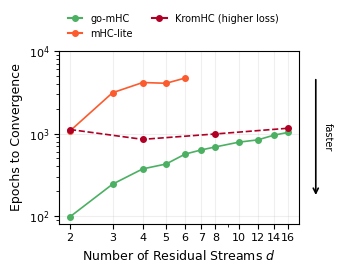

In [115]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

noise_floor = (sweep_config['noise_mag'][0] ** 2) / 3

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    'KromHC': plt.cm.YlOrRd(0.9)
}

dims = sweep_config['n']

def get_loss_at_epoch(history_list, epoch_idx):

    if history_list is None or (hasattr(history_list, '__len__') and len(history_list) == 0):
        return None
    if epoch_idx >= len(history_list):
        return None
    return history_list[epoch_idx]

def get_convergence_epoch(history_list, threshold_frac=0.05):
    if history_list is None or (hasattr(history_list, '__len__') and len(history_list) == 0):
        return None
    final_loss = history_list[-1]
    if final_loss is None:
        return None
    cutoff = final_loss * (1 + threshold_frac)
    for i, val in enumerate(history_list):
        if val is not None and val <= cutoff:
            return i
    return None

fig, ax = plt.subplots(figsize=FIG_SIZE)

print(f"Noise floor: {noise_floor:.6e}")
print(f"5% threshold for convergence to noise floor: {noise_floor * 1.05:.6e}")
print("=" * 70)

for method_name, method_key_fn in [
    ('go-mHC', lambda dim: all_histories[dim].get('gu_2', [])),
    ('mHC-lite', lambda dim: all_histories[dim].get('mhc_lite', [])),
    ('KromHC (higher loss)', lambda dim: all_histories[dim].get('kromhc', [])),
]:
    color = colors_methods[method_name]
    xs = []
    ys = []
    reached_floor = []  # whether final loss is within 5% of noise floor

    print(f"\n{method_name}:")
    for dim_idx, d in enumerate(dims):
        hist = method_key_fn(dim_idx)
        if method_name == 'KromHC' and d.bit_count() != 1:
            continue
        if method_name == 'mHC-lite' and d >= 7:
            continue
        conv_epochs = []
        for single_hist in hist:
            single_conv_epoch = get_convergence_epoch(single_hist)
            conv_epochs.append(single_conv_epoch)
        
        print('conv_epochs:', conv_epochs)
        conv_epoch=np.mean(conv_epochs) if conv_epochs else None
        
        final_loss = np.mean(np.min(hist, axis=1)) if (hist is not None and len(hist) > 0) else None
        #final_loss = np.mean(get_loss_at_epoch(hist, len(hist) - 1)) if (hist is not None and len(hist) > 0) else None
        print("final loss: ", final_loss)
        print("noise_floor", noise_floor)
        at_floor = final_loss is not None and final_loss <= noise_floor * 1.05


        if conv_epoch is not None:
            xs.append(d)
            ys.append(conv_epoch)
            reached_floor.append(at_floor)

    if xs:
        # Determine linestyle: solid if all points reached floor, dashed if not
        print(f"reached_floor for {method_name}: {reached_floor}")
        print(reached_floor)
        all_at_floor = all(reached_floor)
        print(all_at_floor)
        ls = '-' if all_at_floor else '--'

        ax.plot(xs, ys,
                color=color,
                marker='o',
                linestyle=ls,
                markersize=4,
                label=method_name,
                rasterized=True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticks([100, 1000, 10000])

ax.set_xlabel("Number of Residual Streams $d$")
ax.set_ylabel("Epochs to Convergence")
ax.grid(True, which="major", ls="-", alpha=0.2)

# --- Legend: methods + linestyle ---
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, marker='o', markersize=4,
           label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC (higher loss)']
]
style_handles = [
    Line2D([0], [0], color='gray', lw=1.2, linestyle='-', label='Reached ideal loss'),
    Line2D([0], [0], color='gray', lw=1.2, linestyle='--', label='Did not'),
]

legend1 = ax.legend(handles=method_handles,
                    loc='lower left', bbox_to_anchor=(0, 1.02),
                    ncol=2, frameon=False, fontsize=7, handlelength=1.5)
# legend2 = ax.legend(handles=style_handles,
#                     loc='lower left', bbox_to_anchor=(0.0, 1.18),
#                     ncol=3, frameon=False, fontsize=6, handlelength=2.0)
# ax.add_artist(legend1)

ax.annotate(
    '',
    xy=(1.07, 0.15),          # arrowhead (pointing down = lower y)
    xytext=(1.07, 0.85),      # arrow tail (upper y)
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='->', 
        color='black',
        lw=1.2,
    ),
    annotation_clip=False,    # allow drawing outside axes bounds
)

# Label rotated 90° CCW, centred vertically alongside the arrow
ax.annotate(
    'faster',
    xy=(1.10, 0.5),           # midpoint, a little further right of the arrow
    xycoords='axes fraction',
    fontsize=7,
    va='center',
    ha='left',
    rotation=270,             # reads top-to-bottom (downward direction)
    annotation_clip=False,
)

plt.savefig('final_convergence_vs_dim.pdf', bbox_inches='tight', dpi=300)
plt.show()

[314, 440, 274, 742, 715, 266, 649, 457, 1164, 230, 224, 127, 183, 308, 821, 264, 275, 561, 210, 128, 585, 343, 348, 399, 160, 268, 258, 225, 397, 225, 178, 222, 311, 296, 174, 547, 380, 625, 266, 664, 272, 262, 275, 342, 900, 470, 126, 491, 319, 1010, 225, 296, 766, 332, 274, 183, 280, 242, 151, 521, 197, 308, 256, 218]
avg_conv 374.046875
[2640, 6049, 982, 7231, 5705, 2255, 5658, 3565, 5523, 2586, 3565, 2937, 5170, 3354, 7512, 3856, 6069, 7421, 3229, 3274, 5941, 3611, 6327, 4884, 3113, 3312, 5989, 2468, 3855, 3001, 1893, 3235, 5217, 2651, 2987, 3437, 4080, 6197, 3240, 4762, 4494, 3921, 1950, 7549, 6666, 4595, 1717, 5786, 2363, 7247, 2306, 2028, 3077, 7579, 2062, 1936, 4550, 2543, 1661, 5927, 2089, 5267, 4086, 5413]
avg_conv 4149.890625
[1174, 733, 158, 129, 1641, 1530, 484, 718, 39, 728, 1025, 1442, 9, 1771, 1127, 608, 955, 795, 1432, 555, 1978, 16, 1081, 294, 747, 13, 851, 1503, 1339, 1087, 311, 1033, 1002, 585, 1106, 174, 1074, 1363, 547, 1273, 1043, 496, 764, 380, 190, 1125, 765, 

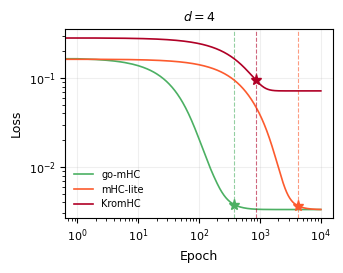

In [137]:
def plot_loss_trajectory(dim_idx, d):
    """Plot loss trajectories for all 3 models at a given matrix dimension d."""
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    for method_name, method_key, skip_fn in [
        ('go-mHC', 'gu_2', lambda d: False),
        ('mHC-lite', 'mhc_lite', lambda d: d >= 7),
        ('KromHC', 'kromhc', lambda d: d.bit_count() != 1),
    ]:
        if skip_fn(d):
            continue
        hist = all_histories[dim_idx].get(method_key, [])
        
        if hist is None or len(hist) == 0:
            continue

        avg_hist=np.mean(hist, axis=0)

        color = colors_methods[method_name]
        ax.plot(range(np.shape(hist)[1]), avg_hist, color=color, label=method_name, linewidth=1.2)
        
        #ax.plot(range(np.shape(hist)[1]), np.quantile(hist, 0.25,axis=0), color=color, label=method_name, linewidth=1.2)


        conv_vals = []
        for single_hist in hist:
            # Mark convergence point
            conv = get_convergence_epoch(single_hist)
            conv_vals.append(conv)
        
        print(conv_vals)
        
        if conv_vals is not None:
            avg_conv=np.mean(conv_vals, axis=0)
            print("avg_conv", avg_conv)

            ax.axvline(x=avg_conv, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
            ax.plot(avg_conv, avg_hist[int(avg_conv)], marker='*', color=color, markersize=8, zorder=5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"$d = {d}$", fontsize=9)
    ax.grid(True, which="major", ls="-", alpha=0.2)
    ax.legend(frameon=False, fontsize=7)
    plt.show()

# Example usage — change the index and d value to inspect different dimensions:
# dims = [2, 3, 4, 5, 6, 7, 8, 10]
#         0  1  2  3  4  5  6  7
plot_loss_trajectory(dim_idx=2, d=4)

# Loss Trajectories by # of residual streams

In [143]:
sweep_config = {
    'n': [2, 3, 4, 5, 6, 8, 10, 12, 14, 16],
    'lr': [0.001],#, 0.005],
    'sparsity': [0], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 10
Running Experiment 1/10: {'n': 2, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.00676362, 0.00643594, 0.00612427, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.03648835, 0.0356864 , 0.03489156, ..., 0.00339938, 0.00339938,
        0.00339938],
       [0.05187423, 0.05059893, 0.04933788, ..., 0.00307797, 0.00307797,
        0.00307798],
       ...,
       [0.00339   , 0.00334009, 0.00330439, ..., 0.00327341, 0.00327342,
        0.00327342],
       [0.26870361, 0.26866591, 0.26860654, ..., 0.00318493, 0.00318493,
        0.00318493],
       [0.14133497, 0.13952139, 0.13771453, ..., 0.00322654, 0.00322654,
        0.00322654]], shape=(64, 10000)), 'gu_2': array([[0.0112594 , 0.01120432, 0.0111513 , ..., 0.00325113, 0.00325114,
        0.00325115],
       [0.0037635 , 0.00367132, 0.00359275, ..., 0

histories:  {'$m$HC-lite': array([[0.03671749, 0.03663191, 0.03654633, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.02985385, 0.02974252, 0.02963137, ..., 0.00339939, 0.00339939,
        0.00339939],
       [0.14371687, 0.14346406, 0.14321122, ..., 0.00307797, 0.00307797,
        0.00307797],
       ...,
       [0.00476007, 0.00473399, 0.00470819, ..., 0.00327341, 0.00327341,
        0.00327341],
       [0.02233577, 0.02223535, 0.02213521, ..., 0.00318493, 0.00318493,
        0.00318493],
       [0.05651309, 0.05634211, 0.0561714 , ..., 0.00322654, 0.00322654,
        0.00322654]], shape=(64, 10000)), 'KromHC': array([[0.02781263, 0.02772898, 0.02764538, ..., 0.00325114, 0.00325114,
        0.00325114],
       [0.00819352, 0.00814935, 0.00810535, ..., 0.00339938, 0.00339938,
        0.00339939],
       [0.1450811 , 0.14482841, 0.14457569, ..., 0.00307797, 0.00307797,
        0.00307797],
       ...,
       [0.15203714, 0.15176436, 0.15149164, ..., 0.00327341, 0.00327341,

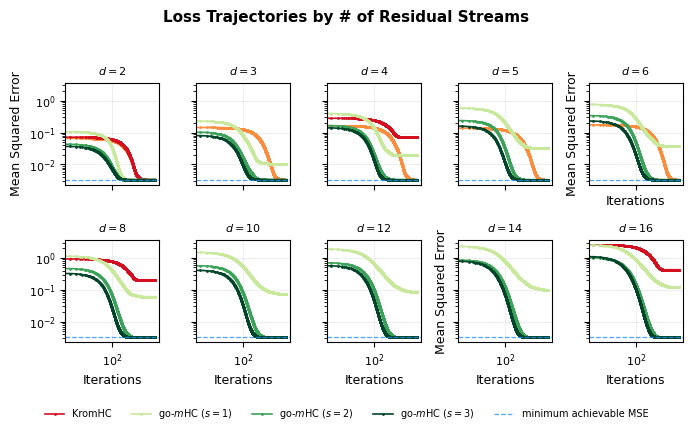

In [144]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 1.2)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})

noise_floor = (sweep_config['noise_mag'][0] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

fig, axes = plt.subplots(2, 5, figsize=FIG_SIZE, sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle("Loss Trajectories by # of Residual Streams", fontsize=11, fontweight='bold')

for dim in range(len(sweep_config['n'])):
    ax = axes[dim]

    histories = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': all_histories[dim]['gu_1'],
        'go-$m$HC ($s=2$)': all_histories[dim]['gu_2'],
        'go-$m$HC ($s=3$)': all_histories[dim]['gu_3']
    }
    if sweep_config['n'][dim].bit_count() == 1:
        histories['KromHC'] = all_histories[dim]['kromhc']
    if sweep_config['n'][dim] < 7:
        histories['$m$HC-lite'] = all_histories[dim]['mhc_lite']

    i = 0
    print('histories: ',histories)
    for label in histories:
        if histories[label] is not None and len(histories[label]) > 0:
            data = np.mean(histories[label], axis=0)
            print('data: ', np.shape(data))
            ax.plot(data, label=label, color=colors[i],
                    alpha=0 if label == " " else 1, marker='.', markersize=2, rasterized=True)
        i += 1

    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d={sweep_config['n'][dim]}$", fontsize=8)
    ax.grid(True, which="major", ls="-", alpha=0.2)

    if dim >= 4:
        ax.set_xlabel("Iterations")
    if dim % 4 == 0:
        ax.set_ylabel("Mean Squared Error")

# Single shared legend from the last subplot's handles
handles, labels = axes[-1].get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l.strip()]

# Append noise floor handle manually
filtered.append((
    Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8),
    'minimum achievable MSE'
))

fig.legend(*zip(*filtered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(filtered),
           frameon=False,
           fontsize=7,
           columnspacing=2)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('appendix_loss_trajectories_by_residual_streams.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Single Loss Curve

In [145]:
sweep_config = {
    'n': [4],
    'lr': [0.001],#, 0.005],
    'sparsity': [0], #sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

all_results, all_histories = run_sweep(sweep_config)

Total experiments to run: 1
Running Experiment 1/1: {'n': 4, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
hist: {'gu_1': array([[0.48459297, 0.48104042, 0.47748226, ..., 0.00456033, 0.00456032,
        0.00456033],
       [0.25628114, 0.25548157, 0.25472316, ..., 0.019949  , 0.01994898,
        0.01994895],
       [0.50965959, 0.5062899 , 0.50292808, ..., 0.00547661, 0.00547661,
        0.00547661],
       ...,
       [0.27395108, 0.27041361, 0.26693818, ..., 0.02996435, 0.02996436,
        0.02996437],
       [0.27089173, 0.26787776, 0.26490229, ..., 0.00465549, 0.00465548,
        0.00465548],
       [0.25898609, 0.25605956, 0.25315392, ..., 0.02609895, 0.02609894,
        0.02609895]], shape=(64, 10000)), 'gu_2': array([[0.11679646, 0.11441061, 0.11204072, ..., 0.00294108, 0.00294106,
        0.00294106],
       [0.09152269, 0.08985309, 0.08819046, ..., 0.0

avg_data:  (10000,)
avg_data:  (10000,)
avg_data:  (10000,)
avg_data:  (10000,)
avg_data:  (10000,)


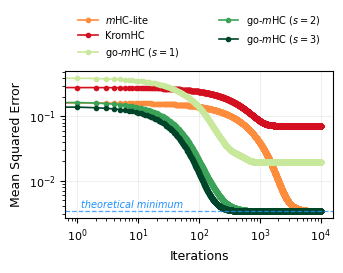

In [146]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5  
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,            
    "font.size": 9,                 
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True       
})

noise_floor = (sweep_config['noise_mag'][0] ** 2) / 3

plt.figure(figsize=FIG_SIZE)

colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

for dim in range(len(sweep_config['n'])):
    histories = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': all_histories[dim]['gu_1'],
        'go-$m$HC ($s=2$)': all_histories[dim]['gu_2'],
        'go-$m$HC ($s=3$)': all_histories[dim]['gu_3']
    }
    if sweep_config['n'][dim].bit_count() == 1:
        histories['KromHC'] = all_histories[dim]['kromhc']

    if sweep_config['n'][dim] < 7:
        histories['$m$HC-lite'] = all_histories[dim]['mhc_lite']

    i = 0
    for label in histories:
        data = histories[label]
        if data is not None and len(data) > 0:
            avg_data = np.mean(data, axis=0)
            print('avg_data: ', np.shape(avg_data))
            plt.plot(avg_data, label=label, color=colors[i],
                    alpha=0 if label == " " else 1, marker='.', rasterized=True)
        i += 1

    plt.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error")
    plt.grid(True, which="major", ls="-", alpha=0.2)

    # --- Annotate noise floor line ---
    ax = plt.gca()
    ax.annotate('theoretical minimum', xy=(0.46, noise_floor-0.0005), xycoords=('axes fraction', 'data'),
                xytext=(-4, 4), textcoords='offset points',
                ha='right', va='bottom',
                color='dodgerblue', fontstyle='italic', fontsize=7)

    # Build legend
    plt.legend(loc='lower center', 
            bbox_to_anchor=(0.5, 1.02), 
            ncol=2, 
            frameon=False, 
            fontsize=7, columnspacing=4)

    plt.savefig('loss_trajectory_with_floor.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [147]:
# reset rcParams to default before applying new style
plt.rcParams.update(plt.rcParamsDefault)

# ICML figure styling with one col (3.25in width)
plt.rcParams.update({
    'font.size': 10,
    'figure.figsize': (3.25, 2.5),
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'legend.loc': 'upper right',
})

In [148]:
# plot the two KromHC (include H_pre vs not) on the same plot for comparison
kromhc_hist_without_pre = all_histories[0]['kromhc']
kromhc_hist_with_pre = all_histories[1]['kromhc']

color_KromHC = plt.cm.YlOrRd(0.8)

plt.figure()
plt.plot(kromhc_hist_with_pre, label="KromHC with $\mathcal{H}^\mathrm{pre}$", color=color_KromHC, linestyle='--')
plt.plot(kromhc_hist_without_pre, label="KromHC without $\mathcal{H}^\mathrm{pre}$", color=color_KromHC)

# shade the area between the two curves after they cross to highlight the difference
crossing_points = np.where(np.diff(np.sign(kromhc_hist_with_pre - kromhc_hist_without_pre)))[0]
if len(crossing_points) > 0:
    last_crossing = crossing_points[-1]
    plt.fill_between(range(last_crossing, len(kromhc_hist_with_pre)), kromhc_hist_with_pre[last_crossing:], kromhc_hist_without_pre[last_crossing:], color='tab:orange', alpha=0.3)
    
    # add annotation in the middle of region "Advantage of $\mathcal{H}^\mathrm{pre}$"
    mid_point = last_crossing + (len(kromhc_hist_with_pre) - last_crossing) // 2
    # plt.annotate("$\mathcal{H}^\mathrm{pre}$ Symmetry Breaking", xy=(mid_point, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2), xytext=(mid_point, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2 * 5), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center')
    plt.text(mid_point + 500, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2 / 1.5, "Advantage of $\mathcal{H}^\mathrm{pre}$", fontsize=10, ha='center')

plt.yscale('log')
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.legend()
# plt.title("KromHC Loss Trajectory Comparison")
plt.grid(True, which="major", ls="-", alpha=0.5)
# remove minor grid
plt.minorticks_off()
plt.savefig("kromhc_symmetry_breaking_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

KeyError: 1

In [ ]:
import pandas as pd
df = pd.DataFrame(all_results)
# set max width of print to fit entire table
pd.set_option('display.max_columns', None)
print(df.sort_values(by='final_loss_mhc_lite'))

   n     lr  sparsity   B  num_epochs  dataset_size  noise_mag  include_H_pre  \
1  4  0.001         0  64       10000           100        0.1           True   
0  4  0.001         0  64       10000           100        0.1          False   

   final_loss_gu_2  final_loss_mhc_lite  final_loss_kromhc  
1         0.002491             0.002502           0.013217  
0         0.003323             0.003326           0.071619  


# Weird Circuit Model

In [87]:
import sympy
import numpy as np

a, b = sympy.symbols('a b')
A, B = np.array([[a, 1-a], [1-a, a]]), np.array([[b, 1-b], [1-b, b]])

# A tensor B to get a 4x4 matrix
Hres = np.kron(A, B)

Hres

array([[a*b, a*(1 - b), b*(1 - a), (1 - a)*(1 - b)],
       [a*(1 - b), a*b, (1 - a)*(1 - b), b*(1 - a)],
       [b*(1 - a), (1 - a)*(1 - b), a*b, a*(1 - b)],
       [(1 - a)*(1 - b), b*(1 - a), a*(1 - b), a*b]], dtype=object)

In [176]:
# cyclic permutation matrix for 4 elements
target = np.array([[0, 0.1, 0, 0.9],
                   [0.5, 0.4, 0, 0],
                   [0.5, 0.4, 0, 0.1],
                   [0, 0, 1, 0]])

target

array([[0. , 0.1, 0. , 0.9],
       [0.5, 0.4, 0. , 0. ],
       [0.5, 0.4, 0. , 0.1],
       [0. , 0. , 1. , 0. ]])

In [177]:
# make a system of equations from Hres, target
H = sympy.Matrix(Hres - target)

# solve for a, b
solution = sympy.solve(H, (a, b))
solution

[]

In [178]:
v = np.array([sympy.Symbol(f"v_{i}") for i in range(4)])

sympy.Matrix(v @ Hres) #.subs({v[0]: 1, v[1]: 0, v[2]: 0, v[3]: 1})

Matrix([
[a*b*v_0 + a*v_1*(1 - b) + b*v_2*(1 - a) + v_3*(1 - a)*(1 - b)],
[a*b*v_1 + a*v_0*(1 - b) + b*v_3*(1 - a) + v_2*(1 - a)*(1 - b)],
[a*b*v_2 + a*v_3*(1 - b) + b*v_0*(1 - a) + v_1*(1 - a)*(1 - b)],
[a*b*v_3 + a*v_2*(1 - b) + b*v_1*(1 - a) + v_0*(1 - a)*(1 - b)]])

In [189]:
w = np.array([sympy.Symbol(f"w_{i}") for i in range(4)])

# w[3:] = 0

# make a system of equations from Hres, target
H = sympy.Matrix(v @ Hres - w @ target)

solution = sympy.solve(H, (v[0], v[1], v[2], v[3], w[0], w[1], w[2], w[3]))
solution

{v_0: w_0*(10.0*a*b - 10.0*a - 9.0*b + 9.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 4.0*a)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - b + 1.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - b)/(4.0*a*b - 2.0*a - 2.0*b + 1.0),
 v_1: w_0*(10.0*a*b - 9.0*b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 5.0*a)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - a - b + 1.0)/(4.0*a*b - 2.0*a - 2.0*b + 1.0),
 v_2: a*b*w_3/(4.0*a*b - 2.0*a - 2.0*b + 1.0) + w_0*(10.0*a*b - 10.0*a - b + 1.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 4.0*a - 9.0*b + 4.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - 9.0*b + 4.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0),
 v_3: w_0*(10.0*a*b - b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 5.0*a - 9.0*b + 5.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - 9.0*b + 5.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - 

In [190]:
solution[v[0]].simplify()#.factor(a, b)

(40.0*a*b*w_0 + 36.0*a*b*w_1 + 40.0*a*b*w_2 + 40.0*a*b*w_3 - 40.0*a*w_0 - 16.0*a*w_1 - 20.0*a*w_2 - 36.0*b*w_0 - 4.0*b*w_2 - 40.0*b*w_3 + 36.0*w_0 + 4.0*w_2)/(160.0*a*b - 80.0*a - 80.0*b + 40.0)

In [187]:
solution[v[2]].simplify()#.factor(a, b)

(10.0*a*b*w_2 + 10.0*a*b*w_3 - 5.0*a*w_2 - 9.0*b*w_2 + w_0*(10.0*a*b - 10.0*a - b + 1.0) + w_1*(9.0*a*b - 4.0*a - 9.0*b + 4.0) + 4.0*w_2)/(40.0*a*b - 20.0*a - 20.0*b + 10.0)

In [ ]:
solution

array([[0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0]])

In [129]:
v @ Hres

array([a*b*v_0 + a*v_1*(1 - b) + b*v_2*(1 - a) + v_3*(1 - a)*(1 - b),
       a*b*v_1 + a*v_0*(1 - b) + b*v_3*(1 - a) + v_2*(1 - a)*(1 - b),
       a*b*v_2 + a*v_3*(1 - b) + b*v_0*(1 - a) + v_1*(1 - a)*(1 - b),
       a*b*v_3 + a*v_2*(1 - b) + b*v_1*(1 - a) + v_0*(1 - a)*(1 - b)],
      dtype=object)

In [ ]:
sympy.Matrix(v @ Hres).subs({v[0]: 1, v[1]: 0, v[2]: 0, v[3]: 0})

Matrix([
[            a*b],
[      a*(1 - b)],
[      b*(1 - a)],
[(1 - a)*(1 - b)]])

In [109]:
sympy.Matrix(v @ Hres).subs({v[0]: 0, v[1]: 0, v[2]: 0, v[3]: 1})

Matrix([
[(1 - a)*(1 - b)],
[      b*(1 - a)],
[      a*(1 - b)],
[            a*b]])

In [111]:
# Compare it with the explicit read at 1 and 3 matrix
R13 = np.array([1, 0, 0, 1])

sympy.Matrix(R13 @ Hres)

Matrix([
[a*b + (1 - a)*(1 - b)],
[a*(1 - b) + b*(1 - a)],
[a*(1 - b) + b*(1 - a)],
[a*b + (1 - a)*(1 - b)]])